# HJ Distance Spanning Test across Penalties ($\lambda$)

This notebook focuses on the **HJ Distance Spanning Test** for the **Consensus-Bottleneck Asset Pricing Model (CB-APM)**.

The goal is to determine if the latent factors (concepts) learned by CB-APM provide incremental pricing information over traditional factor models. We measure this incremental value through the reduction in the **Hansen-Jagannathan (HJ) Distance** when benchmark models are augmented with CB-APM factors.

We compare CB-APM against:
1. **CAPM** (Mkt-RF)
2. **Fama-French 3-Factor** (FF3)
3. **Fama-French 5-Factor** (FF5)
4. **Fama-French 6-Factor** (FF6)

In [17]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
import sys
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from config import get_config
from analysis.util import get_Xy_cbapm

# Set formal plotting style
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 12,
    'axes.linewidth': 1.2,
    'figure.figsize': (12, 7)
})

## 1. Parameters and Benchmarks

Define the range of $\lambda$ and the benchmark models to be tested.

In [34]:
horizon = '12month' 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lambdas = [round(x * 0.1, 1) for x in range(0, 11)]
train_date = '2020-01-01'

benchmarks = {
    'CAPM': ['Mkt-RF'],
    'FF3': ['Mkt-RF', 'SMB', 'HML'],
    'FF5': ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA'],
    'FF6': ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'UMD']
}

## 2. Data Loading

Load benchmark factors and test assets (FF 25 Portfolios).

In [3]:
def load_ff_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    col_orig = df.columns[0]
    df[col_orig] = df[col_orig].astype(str).str.strip()
    df = df[df[col_orig].str.match(r'^\d{6}$')].copy()
    df['date'] = pd.to_datetime(df[col_orig], format='%Y%m')
    df = df.set_index('date')
    if col_orig != 'date':
        df = df.drop(columns=[col_orig], errors='ignore')
    return df.astype(float) / 100.0

print("Loading factors and test assets...")
ff5_df = load_ff_csv('../data/F-F_Research_Data_5_Factors_2x3.csv')
mom_df = load_ff_csv('../data/F-F_Momentum_Factor.csv').rename(columns={'Mom': 'UMD'})
rf = ff5_df['RF']
all_bench_factors = pd.concat([ff5_df.drop(columns=['RF']), mom_df], axis=1).dropna()

portfolio_files = {
    '25_Portfolios_5x5': '../data/25_Portfolios_5x5.csv',
    '25_Portfolios_ME_Prior_12_2': '../data/25_Portfolios_ME_Prior_12_2.csv',
    '30_Industry_Portfolios': '../data/30_Industry_Portfolios.csv'
}

portfolios_ex = {}
for name, path in portfolio_files.items():
    print(f"  Loading {name}...")
    df = load_ff_csv(path)
    df_ex = df.sub(rf, axis=0).drop(columns=['RF'], errors='ignore').dropna()
    portfolios_ex[name] = df_ex

print("Loading CB-APM base data...")
input_df = pd.read_csv(f'../data/input_{horizon}.csv')
target_df = pd.read_csv(f'../data/target_{horizon}.csv')
input_df['date'] = pd.to_datetime(input_df['date'])
target_df['date'] = pd.to_datetime(target_df['date'])
signal_info = pd.read_csv('../data/info/SignalDoc.csv')
info = signal_info[signal_info['Acronym'].isin(input_df.columns)]

Loading factors and test assets...
  Loading 25_Portfolios_5x5...
  Loading 25_Portfolios_ME_Prior_12_2...
  Loading 30_Industry_Portfolios...
Loading CB-APM base data...


## 3. HJ Distance Calculation Utilities

In [32]:
def get_implied_sdf(factors, returns_ex):
    f = factors.values if isinstance(factors, pd.DataFrame) else factors
    r = returns_ex.values if isinstance(returns_ex, pd.DataFrame) else returns_ex
    
    f_bar = f.mean(axis=0)
    f_adj = f - f_bar
    sigma_f = np.cov(f, rowvar=False)
    if sigma_f.ndim == 0: sigma_f = sigma_f.reshape(1,1)
    
    sigma_f_inv = np.linalg.pinv(sigma_f)
    # E[f R^e]
    pricing_errors_f = (f.T @ r / len(f)).mean(axis=1)
    b = sigma_f_inv @ pricing_errors_f
    
    return 1 - f_adj @ b

def calculate_hj_distance(sdf, returns_ex):
    r = returns_ex.values if isinstance(returns_ex, pd.DataFrame) else returns_ex
    pricing_errors = (sdf[:, None] * r).mean(axis=0)
    cov_inv = np.linalg.pinv(np.cov(r, rowvar=False))
    hjd = np.sqrt(pricing_errors.T @ cov_inv @ pricing_errors)
    return hjd

## 4. Multi-Benchmark Spanning Analysis

Iterate through $\lambda$ and compare CB-APM's contribution to each benchmark.

In [35]:
# Store results for each portfolio
portfolio_results = {}

for port_name, ta_ex in portfolios_ex.items():
    print(f"\nAnalysing Portfolio: {port_name}")
    analysis_results = []
    
    for lam in tqdm(lambdas, desc=f"Analyzing Lambdas for {port_name}"):
        # 1. Extract CB-APM Factors
        config = get_config(lam)
        X_cbapm, _ = get_Xy_cbapm(
            train_date=train_date, 
            input=input_df, 
            target=target_df, 
            info=info, 
            config=config, 
            device=device, 
            horizon=horizon, 
            weight_lambda=lam,
            embedding_method='autoencoder'
        )
        X_cbapm['date'] = pd.to_datetime(X_cbapm['date'])
        concepts_ts = X_cbapm.groupby('date').mean().drop(columns=['permno'], errors='ignore')
        
        # 2. Align with Benchmarks and Assets
        common_idx = concepts_ts.index.intersection(ta_ex.index).intersection(all_bench_factors.index)
        c_ts = concepts_ts.loc[common_idx]
        p_ex = ta_ex.loc[common_idx]
        bench_f = all_bench_factors.loc[common_idx]
        
        row = {'lambda': lam}
        
        for name, cols in benchmarks.items():
            b_data = bench_f[cols]
            
            # Benchmark only
            sdf_b = get_implied_sdf(b_data, p_ex)
            hjd_b = calculate_hj_distance(sdf_b, p_ex)
            
            # Benchmark + CB-APM
            aug_data = pd.concat([b_data, c_ts], axis=1)
            sdf_aug = get_implied_sdf(aug_data, p_ex)
            hjd_aug = calculate_hj_distance(sdf_aug, p_ex)
            
            reduction = (hjd_b - hjd_aug) / hjd_b
            
            row[f'{name}_hjd'] = hjd_b
            row[f'{name}_aug_hjd'] = hjd_aug
            row[f'{name}_reduction'] = reduction
            
        analysis_results.append(row)
    
    portfolio_results[port_name] = pd.DataFrame(analysis_results)
    
print("\nAll analyses complete.")


Analysing Portfolio: 25_Portfolios_5x5


Analyzing Lambdas for 25_Portfolios_5x5: 100%|██████████| 11/11 [04:46<00:00, 26.01s/it]



Analysing Portfolio: 25_Portfolios_ME_Prior_12_2


Analyzing Lambdas for 25_Portfolios_ME_Prior_12_2: 100%|██████████| 11/11 [05:07<00:00, 27.93s/it]



Analysing Portfolio: 30_Industry_Portfolios


Analyzing Lambdas for 30_Industry_Portfolios: 100%|██████████| 11/11 [05:23<00:00, 29.43s/it]


All analyses complete.


## 5. Visualization of Spanning Performance

We plot the HJ Distance reduction across different benchmarks to visualize how CB-APM complements existing models.

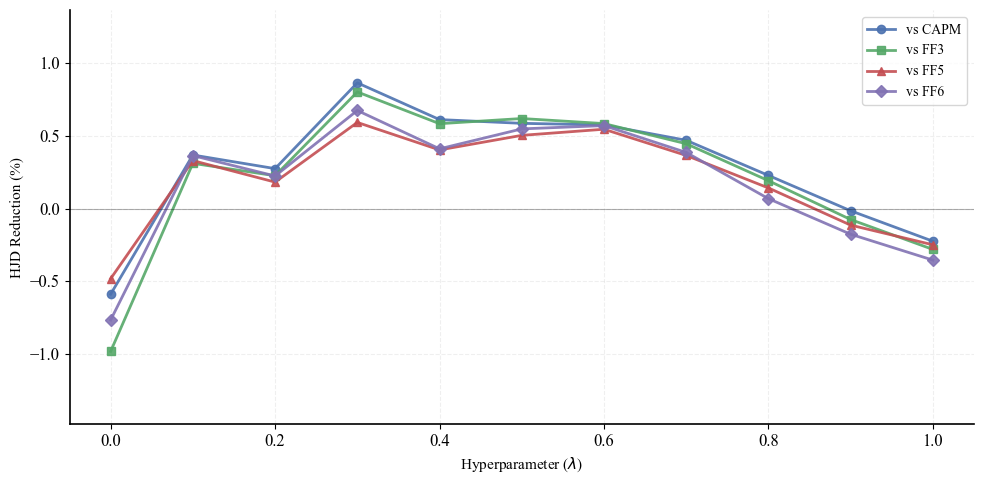

Reduction Statistics for 25_Portfolios_5x5:


,lambda,CAPM_reduction,FF3_reduction,FF5_reduction,FF6_reduction
0,0.0,-0.005880,-0.009805,-0.004814,-0.007652
1,0.1,0.003678,0.003106,0.003293,0.003637
2,0.2,0.002742,0.002255,0.001816,0.002237
3,0.3,0.008633,0.008008,0.005914,0.006734
4,0.4,0.006109,0.005828,0.004026,0.004102
5,0.5,0.005852,0.006182,0.005027,0.005470
6,0.6,0.005741,0.005835,0.005447,0.005697
7,0.7,0.004687,0.004451,0.003648,0.003854
8,0.8,0.002275,0.001914,0.001416,0.000680
9,0.9,-0.000151,-0.000753,-0.001136,-0.001762


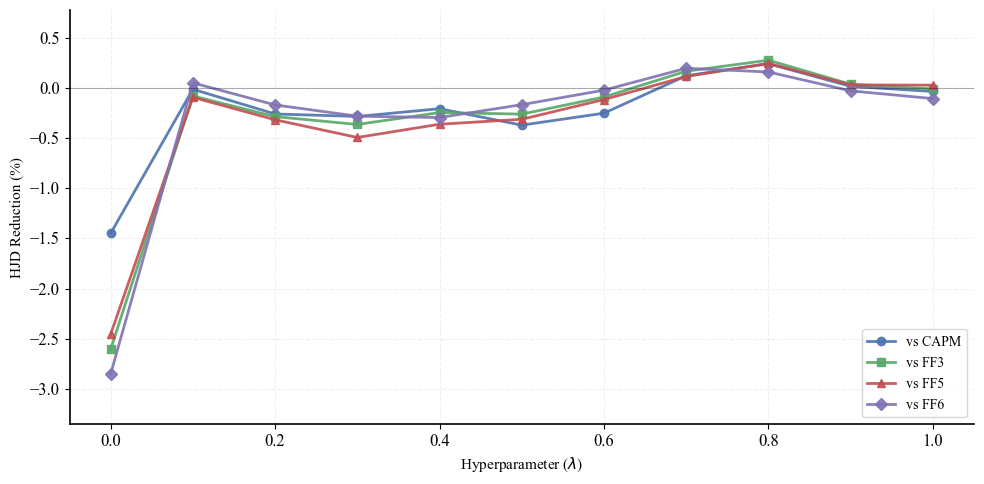

Reduction Statistics for 25_Portfolios_ME_Prior_12_2:


,lambda,CAPM_reduction,FF3_reduction,FF5_reduction,FF6_reduction
0,0.0,-0.014489,-0.026034,-0.024538,-0.028495
1,0.1,-0.000137,-0.000810,-0.000943,0.000500
2,0.2,-0.002598,-0.002862,-0.003176,-0.001699
3,0.3,-0.002846,-0.003642,-0.004939,-0.002818
4,0.4,-0.002073,-0.002461,-0.003620,-0.002956
5,0.5,-0.003712,-0.002614,-0.003129,-0.001671
6,0.6,-0.002519,-0.000909,-0.001163,-0.000226
7,0.7,0.001212,0.001659,0.001135,0.001952
8,0.8,0.002404,0.002755,0.002428,0.001583
9,0.9,0.000155,0.000360,0.000294,-0.000298


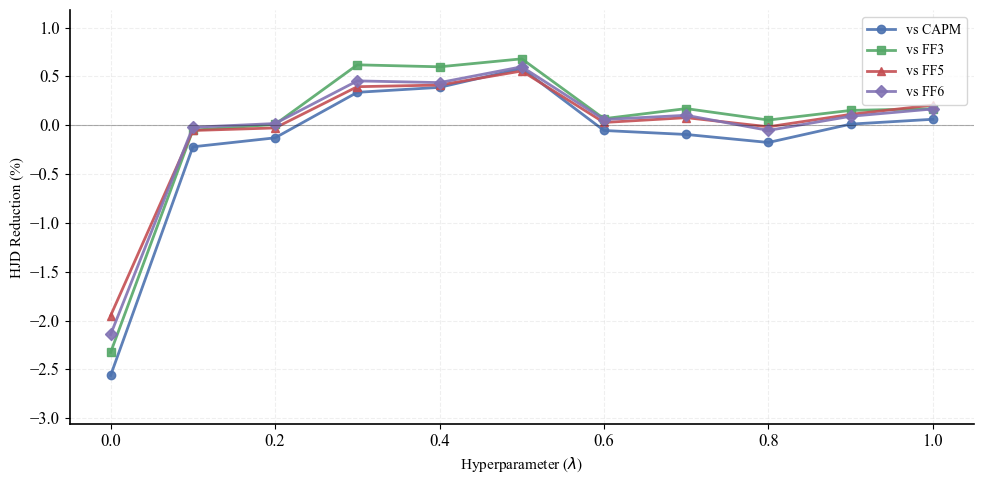

Reduction Statistics for 30_Industry_Portfolios:


,lambda,CAPM_reduction,FF3_reduction,FF5_reduction,FF6_reduction
0,0.0,-0.025612,-0.023256,-0.019491,-0.021424
1,0.1,-0.002207,-0.000506,-0.000537,-0.000208
2,0.2,-0.001289,0.000089,-0.000275,0.000176
3,0.3,0.003371,0.006186,0.003947,0.004541
4,0.4,0.003879,0.005984,0.004115,0.004365
5,0.5,0.005819,0.006799,0.005554,0.005987
6,0.6,-0.000538,0.000673,0.000283,0.000587
7,0.7,-0.000945,0.001704,0.000776,0.001018
8,0.8,-0.001765,0.000532,-0.000157,-0.000530
9,0.9,0.000115,0.001518,0.001116,0.000918


In [41]:
for port_name, df_res in portfolio_results.items():
    plt.figure(figsize=(10, 5))
    # Professional muted color palette often used in analysis reports
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3']
    markers = ['o', 's', '^', 'D', 'v', 'x', '*']

    for i, name in enumerate(benchmarks.keys()):
        plt.plot(df_res['lambda'], df_res[f'{name}_reduction'] * 100, 
                 marker=markers[i % len(markers)], 
                 markersize=6,
                 label=f'vs {name}', 
                 color=colors[i % len(colors)], 
                 linewidth=2,
                 alpha=0.9)

    plt.xlabel('Hyperparameter ($\lambda$)', fontsize=11)
    plt.ylabel('HJD Reduction (%)', fontsize=11)
    
    plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    plt.grid(True, axis='both', alpha=0.2, linestyle='--')
    
    # Remove top and right spines for a modern, clean look
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.legend(frameon=True, facecolor='white', framealpha=0.8, loc='best', fontsize=10)
    
    # Calculate dynamic y-axis limits with padding
    y_vals = df_res[[f'{n}_reduction' for n in benchmarks.keys()]].values * 100
    y_min, y_max = y_vals.min(), y_vals.max()
    plt.ylim(y_min - 0.5, y_max + 0.5)

    plt.tight_layout()
    plt.show()

    print(f"Reduction Statistics for {port_name}:")
    display(df_res[['lambda'] + [f'{n}_reduction' for n in benchmarks.keys()]])